# Convective quench of a long rectangular bar (2D Cartesian, product solution) 

A long bar of rectangular cross-section $a\times b$, initially at uniform $T_i$, is suddenly exposed at $t=0$ to convection $(h, T_\infty)$ on all four side faces (@fig-bar).

$$
\frac{\partial T}{\partial t}
=
\alpha\left[
\frac{\partial^2 T}{\partial x^2}
+
\frac{\partial^2 T}{\partial y^2}
\right],
\qquad
|x|\le a/2,\ |y|\le b/2,
$$

with convective BCs on all four faces and symmetry $(\partial T/\partial x = \partial T/\partial y = 0)$ at the centreline $x=0,\ y=0$.

**Data:** $a=0.10\ \text{m}$, $b=0.06\ \text{m}$, $k=15\ \text{W/(m.K)}$, $\alpha=4.0\times 10^{-6}\ \text{m}^2/\text{s}$, $h=100\ \text{W/(m}^2\text{.K)}$, $T_i=200^\circ\text{C}$, $T_\infty=25^\circ\text{C}$. (Half-widths $L_1=a/2=0.05\ \text{m}$, $L_2=b/2=0.03\ \text{m}$; $Bi_1=hL_1/k=0.333$, $Bi_2=hL_2/k=0.2$.)


**Analytical (product-solution) benchmark.** With $x,y$ measured from the centreline, the 1D convectively-cooled infinite-slab solution (half-thickness $L$, $Bi=hL/k$, $Fo=\alpha t/L^2$) is

$$
\frac{\theta_{\text{slab}}(x,t)}{\theta_i}
=
\sum_{n=1}^{\infty}
\frac{4\sin\lambda_n}{2\lambda_n+\sin 2\lambda_n}
e^{-\lambda_n^2Fo}
\cos\left(\lambda_n\frac{x}{L}\right),
\qquad
\lambda_n\tan\lambda_n=Bi.
$$

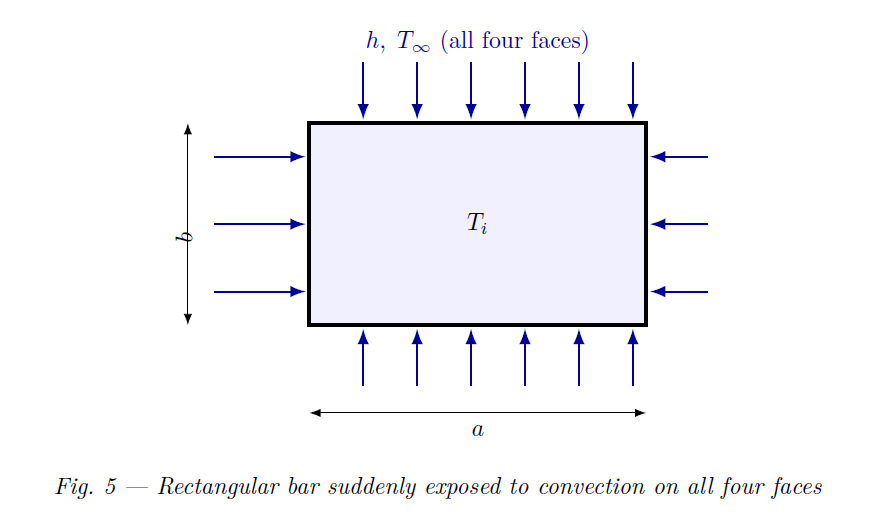{#fig-bar width=65%}


The rectangular bar's 2D solution is the *product* of two such 1D solutions, one per direction:

$$
\frac{\theta(x,y,t)}{\theta_i}
=
\frac{\theta_{\text{slab},1}(x,t)}{\theta_i}
\cdot
\frac{\theta_{\text{slab},2}(y,t)}{\theta_i}.
$$

## Tasks:

(a) Derive the 2D explicit finite-difference update and show that, for $\Delta x = \Delta y = h$, stability requires $Fo = \alpha\Delta t/h^2 \le \frac{1}{4}$ (i.e. half as permissive as the 1D limit, because both directions contribute to diffusive loss from each node).

(b) Implement explicit, fully implicit, Crank–Nicolson, *and* ADI (Peaceman–Rachford) time marching. For ADI, state the tridiagonal sweep sequence you use.

(c) Compute the two 1D slab solutions (find $\lambda_n$ roots for $Bi_1$ and $Bi_2$ separately) and form the product-solution benchmark. Compare your 2D numerical results against it at the centre and at $(a/4,0)$, $(0,b/4)$ for several $Fo$, tabulating the maximum error.

(d) Compare all four schemes on cost (time steps, CPU time, and — for ADI — number of tridiagonal solves per step) needed to reach a fixed accuracy, and discuss why ADI is attractive for 2D problems relative to a fully implicit scheme solved with a general (non-ADI) linear solver.

### Task (a):  Derivation of the 2D Explicit Finite-Difference Update

The governing 2D heat equation from the problem statement is:

$$
\frac{\partial T}{\partial t} = \alpha \left[ \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right]
$$

To derive the explicit scheme, we use the Forward-Time, Centered-Space (FTCS) finite-difference approximation:

1. **Discretize the time derivative** using a forward difference:

$$
\frac{\partial T}{\partial t} \approx \frac{T_{i,j}^{n+1} - T_{i,j}^n}{\Delta t}
$$

2. **Discretize the spatial derivatives** using central differences at time step $n$:

$$
\frac{\partial^2 T}{\partial x^2} \approx \frac{T_{i+1,j}^n - 2T_{i,j}^n + T_{i-1,j}^n}{\Delta x^2}
$$

$$
\frac{\partial^2 T}{\partial y^2} \approx \frac{T_{i,j+1}^n - 2T_{i,j}^n + T_{i,j-1}^n}{\Delta y^2}
$$

3. **Substitute these into the heat equation:**

$$
\frac{T_{i,j}^{n+1} - T_{i,j}^n}{\Delta t} = \alpha \left[ \frac{T_{i+1,j}^n - 2T_{i,j}^n + T_{i-1,j}^n}{\Delta x^2} + \frac{T_{i,j+1}^n - 2T_{i,j}^n + T_{i,j-1}^n}{\Delta y^2} \right]
$$

4. **Apply the uniform grid assumption** given in the task ($\Delta x = \Delta y = h$) and multiply both sides by $\Delta t$:

$$
T_{i,j}^{n+1} - T_{i,j}^n = \frac{\alpha \Delta t}{h^2} \left[ T_{i+1,j}^n - 2T_{i,j}^n + T_{i-1,j}^n + T_{i,j+1}^n - 2T_{i,j}^n + T_{i,j-1}^n \right]
$$

5. **Define the grid Fourier number** as $Fo = \frac{\alpha \Delta t}{h^2}$ and group the terms to solve for the future temperature $T_{i,j}^{n+1}$:

$$
T_{i,j}^{n+1} = T_{i,j}^n + Fo \left[ T_{i+1,j}^n + T_{i-1,j}^n + T_{i,j+1}^n + T_{i,j-1}^n - 4T_{i,j}^n \right]
$$

6. **Final Explicit Update Equation:**

$$
T_{i,j}^{n+1} = Fo(T_{i+1,j}^n + T_{i-1,j}^n + T_{i,j+1}^n + T_{i,j-1}^n) + (1 - 4Fo)T_{i,j}^n
$$ {#eq-explicit}




**7. Inner Symmetry Boundaries**

At the centrelines, the temperature gradient is zero.

* **Left Boundary ($x = 0$, $i=0$):**
The symmetry condition $\frac{\partial T}{\partial x} = 0$. Using a central difference, the fictitious node outside the boundary equals the interior node: $T_{-1,j}^n = T_{1,j}^n$. Substituting this into the explicit update gives:

$$
T_{0,j}^{n+1} = T_{0,j}^n + Fo \left( 2T_{1,j}^n + T_{0,j+1}^n + T_{0,j-1}^n - 4T_{0,j}^n \right)
$$

* **Bottom Boundary ($y = 0$, $j=0$):**
Similarly, $\frac{\partial T}{\partial y} = 0$, meaning $T_{i,-1}^n = T_{i,1}^n$:

$$
T_{i,0}^{n+1} = T_{i,0}^n + Fo \left( T_{i+1,0}^n + T_{i-1,0}^n + 2T_{i,1}^n - 4T_{i,0}^n \right)
$$

* **Absolute Centre Node ($x=0, y=0$, $i=0, j=0$):**
Combining both symmetry conditions:

$$
T_{0,0}^{n+1} = T_{0,0}^n + 2Fo \left( T_{1,0}^n + T_{0,1}^n - 2T_{0,0}^n \right)
$$

**8. Outer Convective Boundaries**

At the outer faces, conduction to the surface equals convection away from it: $-k \frac{\partial T}{\partial \eta} = h_{conv}(T - T_\infty)$, where $\eta$ is the normal direction.

* **Right Boundary ($x = a/2$, $i=N_x$):**
Central difference gives $-k \frac{T_{N_x+1, j}^n - T_{N_x-1, j}^n}{2\Delta x} = h_{conv}(T_{N_x, j}^n - T_\infty)$. Solving for the ghost node yields $T_{N_x+1, j}^n = T_{N_x-1, j}^n - 2Bi_g(T_{N_x, j}^n - T_\infty)$. Substituting this into the explicit scheme yields:

$$
T_{N_x,j}^{n+1} = T_{N_x,j}^n + Fo \left[ 2T_{N_x-1,j}^n + T_{N_x,j+1}^n + T_{N_x,j-1}^n + 2Bi_g T_\infty - (4 + 2Bi_g)T_{N_x,j}^n \right]
$$

* **Top Boundary ($y = b/2$, $j=N_y$):**
Applying the exact same logic for the $y$-direction ghost node:

$$
T_{i,N_y}^{n+1} = T_{i,N_y}^n + Fo \left[ T_{i+1,N_y}^n + T_{i-1,N_y}^n + 2T_{i,N_y-1}^n + 2Bi_g T_\infty - (4 + 2Bi_g)T_{i,N_y}^n \right]
$$

Where $Bi_g$ is the grid biot number.  

**9. Outer Corner Node (Convection on Two Faces)**

* **Top-Right Corner ($x = a/2, y = b/2$, $i=N_x, j=N_y$):**
This node is exposed to convection in both the $x$ and $y$ directions. We must substitute ghost nodes for both $T_{N_x+1, N_y}^n$ and $T_{N_x, N_y+1}^n$:

$$
T_{N_x,N_y}^{n+1} = T_{N_x,N_y}^n + 2Fo \left[ T_{N_x-1,N_y}^n + T_{N_x,N_y-1}^n + 2Bi_g T_\infty - (2 + 2Bi_g)T_{N_x,N_y}^n \right]
$$

**10. Stability condition:**
To determine the stability limit using Von Neumann stability analysis.

We start with the 2D explicit FTCS (Forward-Time, Centered-Space) update equation derived earlier:

$$
T_{i,j}^{n+1} = T_{i,j}^n + Fo \left( T_{i+1,j}^n + T_{i-1,j}^n + T_{i,j+1}^n + T_{i,j-1}^n - 4T_{i,j}^n \right)
$$

***Define the error mode***

Assume the numerical error can be expressed as a Fourier mode:

$$
T_{i,j}^n = G^n e^{I(k_x x_i + k_y y_j)}
$$

where:

* $G$ is the amplification factor between time steps (i.e., $T^{n+1} = G T^n$).
* $I = \sqrt{-1}$ is the imaginary unit.
* $k_x, k_y$ are the spatial wavenumbers.
* $x_i = i\Delta x$ and $y_j = j\Delta y$.

***Substitute into the difference equation***

For a uniform grid where $\Delta x = \Delta y = h$, the neighboring nodes at time $n$ are:

$$
T_{i\pm 1, j}^n = T_{i,j}^n e^{\pm I k_x h}
$$

$$
T_{i, j\pm 1}^n = T_{i,j}^n e^{\pm I k_y h}
$$

$$
T_{i,j}^{n+1} = G T_{i,j}^n
$$

Substitute these into the explicit update equation:

$$
G T_{i,j}^n = T_{i,j}^n + Fo \cdot T_{i,j}^n \left( e^{I k_x h} + e^{-I k_x h} + e^{I k_y h} + e^{-I k_y h} - 4 \right)
$$

***Solve for the amplification factor $G$***

Divide the entire equation by $T_{i,j}^n$:

$$
G = 1 + Fo \left( (e^{I k_x h} + e^{-I k_x h}) + (e^{I k_y h} + e^{-I k_y h}) - 4 \right)
$$

Using Euler's formula ($e^{I\theta} + e^{-I\theta} = 2\cos\theta$), this simplifies to:

$$
G = 1 + 2Fo \left( \cos(k_x h) + \cos(k_y h) - 2 \right)
$$

$$
G = 1 + 2Fo \left( (\cos(k_x h) - 1) + (\cos(k_y h) - 1) \right)
$$

Apply the half-angle trigonometric identity $\cos\theta - 1 = -2\sin^2(\theta/2)$:

$$
G = 1 - 4Fo \left( \sin^2\left(\frac{k_x h}{2}\right) + \sin^2\left(\frac{k_y h}{2}\right) \right)
$$

***Apply the stability criterion***

For a scheme to be stable, the error must not grow unbounded over time. This requires the magnitude of the amplification factor to be less than or equal to 1 for all possible wavenumbers:

$$
-1 \le G \le 1
$$

Substitute $G$:

$$
-1 \le 1 - 4Fo \left( \sin^2\left(\frac{k_x h}{2}\right) + \sin^2\left(\frac{k_y h}{2}\right) \right) \le 1
$$

The right side of the inequality ($\le 1$) is always satisfied because $Fo > 0$ and the squared sine terms are always non-negative.

To satisfy the left side of the inequality ($\ge -1$):

$$
-1 \le 1 - 4Fo \left( \sin^2\left(\frac{k_x h}{2}\right) + \sin^2\left(\frac{k_y h}{2}\right) \right)
$$

$$
4Fo \left( \sin^2\left(\frac{k_x h}{2}\right) + \sin^2\left(\frac{k_y h}{2}\right) \right) \le 2
$$

We must consider the worst-case scenario. The maximum possible value for a sine squared function is 1. Therefore, the maximum value of the bracketed term is $1 + 1 = 2$.

Substitute the worst-case maximum back into the inequality:

$$
4Fo \times 2 \le 2
$$

$$
8Fo \le 2
$$

$$
Fo \le \frac{1}{4}
$$

This confirms the stability limit $Fo \le \frac{1}{4}$ for the 2D explicit scheme.

# Task (b)

Formulating four different time-marching schemes for the 2D heat equation on a uniform grid ($\Delta x = \Delta y = h$). Let the grid Fourier number be defined based on the full time step $\Delta t$:

$$
Fo = \frac{\alpha \Delta t}{h^2}
$$

### 1. Explicit Scheme

The explicit scheme (Forward-Time, Centered-Space) evaluates all spatial derivatives at the known current time step $n$. This scheme is conditionally stable ($Fo \le 1/4$). It is the same update as @eq-explicit, written with the second differences grouped.

$$
T_{i,j}^{n+1} = T_{i,j}^n + Fo \left( (T_{i-1,j}^n - 2T_{i,j}^n + T_{i+1,j}^n) + (T_{i,j-1}^n - 2T_{i,j}^n + T_{i,j+1}^n) \right)
$$

### 2. Fully Implicit Scheme

The fully implicit scheme (Backward-Time, Centered-Space) evaluates all spatial derivatives at the unknown future time step $n+1$. This is unconditionally stable but requires solving a large system of linear equations simultaneously for all nodes.

$$
T_{i,j}^{n+1} = T_{i,j}^n + Fo \left( (T_{i-1,j}^{n+1} - 2T_{i,j}^{n+1} + T_{i+1,j}^{n+1}) + (T_{i,j-1}^{n+1} - 2T_{i,j}^{n+1} + T_{i,j+1}^{n+1}) \right)
$$

Rearranging to place unknowns on the left-hand side and knowns on the right:

$$
-Fo T_{i-1,j}^{n+1} - Fo T_{i,j-1}^{n+1} + (1 + 4Fo) T_{i,j}^{n+1} - Fo T_{i+1,j}^{n+1} - Fo T_{i,j+1}^{n+1} = T_{i,j}^n
$$

### 3. Crank-Nicolson Scheme

The Crank-Nicolson scheme evaluates the spatial derivatives as an average of time steps $n$ and $n+1$. It is unconditionally stable and provides second-order accuracy in time.
$$
\begin{aligned}
T_{i,j}^{n+1} = T_{i,j}^n + \frac{Fo}{2} \left[ (T_{i-1,j}^n - 2T_{i,j}^n + T_{i+1,j}^n) + (T_{i,j-1}^n - 2T_{i,j}^n + T_{i,j+1}^n) \right. \\
\left. + (T_{i-1,j}^{n+1} - 2T_{i,j}^{n+1} + T_{i+1,j}^{n+1}) + (T_{i,j-1}^{n+1} - 2T_{i,j}^{n+1} + T_{i,j+1}^{n+1}) \right]
\end{aligned}
$$

Expanding and grouping unknowns on the left:

$$
\begin{aligned}
-\frac{Fo}{2} T_{i-1,j}^{n+1} - \frac{Fo}{2} T_{i,j-1}^{n+1} + (1 + 2Fo) T_{i,j}^{n+1} - \frac{Fo}{2} T_{i+1,j}^{n+1} - \frac{Fo}{2} T_{i,j+1}^{n+1} = \\ \frac{Fo}{2} T_{i-1,j}^n + \frac{Fo}{2} T_{i,j-1}^n + (1 - 2Fo) T_{i,j}^n + \frac{Fo}{2} T_{i+1,j}^n + \frac{Fo}{2} T_{i,j+1}^n
\end{aligned}
$$

### 4. ADI (Peaceman-Rachford) Tridiagonal Sweep Sequence

The Alternating Direction Implicit (ADI) method splits the time step $\Delta t$ into two half-steps ($\Delta t/2$). This reduces the computationally expensive 2D pentadiagonal matrix problem into a series of highly efficient 1D tridiagonal matrix solves (using Thomas algorithm).

**Sweep 1 (Row-by-Row): Implicit in $x$, Explicit in $y$**
Advance from $t_n$ to an intermediate step $t_{n+1/2}$. For each fixed row $j$, solve the following tridiagonal system for the unknowns in the $x$-direction:

$$
T_{i,j}^{n+1/2} - T_{i,j}^n = \frac{Fo}{2} \left( (T_{i-1,j}^{n+1/2} - 2T_{i,j}^{n+1/2} + T_{i+1,j}^{n+1/2}) + (T_{i,j-1}^n - 2T_{i,j}^n + T_{i,j+1}^n) \right)
$$

Rearranged for the linear solver:

$$
-\frac{Fo}{2} T_{i-1,j}^{n+1/2} + (1 + Fo) T_{i,j}^{n+1/2} - \frac{Fo}{2} T_{i+1,j}^{n+1/2} = \frac{Fo}{2} T_{i,j-1}^n + (1 - Fo) T_{i,j}^n + \frac{Fo}{2} T_{i,j+1}^n
$$

**Sweep 2 (Column-by-Column): Implicit in $y$, Explicit in $x$**
Advance from $t_{n+1/2}$ to $t_{n+1}$. Using the newly computed intermediate values, solve a tridiagonal system along each fixed column $i$ for the unknowns in the $y$-direction:

$$
T_{i,j}^{n+1} - T_{i,j}^{n+1/2} = \frac{Fo}{2} \left( (T_{i-1,j}^{n+1/2} - 2T_{i,j}^{n+1/2} + T_{i+1,j}^{n+1/2}) + (T_{i,j-1}^{n+1} - 2T_{i,j}^{n+1} + T_{i,j+1}^{n+1}) \right)
$$

Rearranged for the linear solver:

$$
-\frac{Fo}{2} T_{i,j-1}^{n+1} + (1 + Fo) T_{i,j}^{n+1} - \frac{Fo}{2} T_{i,j+1}^{n+1} = \frac{Fo}{2} T_{i-1,j}^{n+1/2} + (1 - Fo) T_{i,j}^{n+1/2} + \frac{Fo}{2} T_{i+1,j}^{n+1/2}
$$

# Task (b) continued and first part of task (c):

In [119]:
#| label: tbl-lambda
#| tbl-cap: 'First ten roots of $\lambda\tan\lambda = Bi$ for the $x$-direction ($Bi_1 = 0.333$) and the $y$-direction ($Bi_2 = 0.200$).'
#Setup, Physical Parameters & Eigenvalue (Lambda) Computations
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import time

# 1. Physical parameters
a, b = 0.10, 0.06           # Full widths (m)
L1, L2 = a / 2.0, b / 2.0   # Quarter domain half-widths (m)
k = 15.0                    # Thermal conductivity W/(m.K)
alpha = 4.0e-6              # Diffusivity m^2/s
h_conv = 100.0              # Convection coefficient W/(m^2.K)
Ti, Tinf = 200.0, 25.0      # Temperatures (°C)

Bi1 = h_conv * L1 / k       # 0.333
Bi2 = h_conv * L2 / k       # 0.200

# 2. Grid definition
dx = dy = 0.0025             # Spatial step size
Nx = int(L1 / dx) + 1       # Total nodes in x (21 nodes)
Ny = int(L2 / dy) + 1       # Total nodes in y (13 nodes)
Bi_g = h_conv * dx / k      # Grid Biot number

x_grid = np.linspace(0, L1, Nx)
y_grid = np.linspace(0, L2, Ny)

# Target coordinates for verification[cite: 2]
target_coords = [(0, 0), (a/4, 0), (0, b/4)]
target_indices = [(int(cx/dx), int(cy/dy)) for cx, cy in target_coords]

# 3. Compute eigenvalues (Lambdas) for analytical solution[cite: 1]
def get_eigenvalues(Bi, num_roots=20):
    roots = []
    for n in range(1, num_roots + 1):
        left = (n - 1) * np.pi + 1e-5
        right = (n - 1) * np.pi + np.pi / 2.0 - 1e-5
        res = root_scalar(lambda lam: lam * np.tan(lam)\
                - Bi, bracket=[left, right], method='bisect')
        roots.append(res.root)
    return np.array(roots)

lam1 = get_eigenvalues(Bi1)
lam2 = get_eigenvalues(Bi2)

# Display calculated Lambda values cleanly
lambda_df = pd.DataFrame({
    'n': range(1, 11),
    'lambda_1n (x-direction, Bi=0.333)': lam1[:10],
    'lambda_2n (y-direction, Bi=0.200)': lam2[:10]
})
lambda_df.set_index('n', inplace=True)
display(lambda_df)

,"lambda_1n (x-direction, Bi=0.333)","lambda_2n (y-direction, Bi=0.200)"
n,,
1,0.547161,0.432841
2,3.243987,3.203935
3,6.335748,6.314846
4,9.459999,9.445948
5,12.592835,12.582265
6,15.729152,15.720685
7,18.867221,18.860160
8,22.006295,22.000239
9,25.145996,25.140696


In [10]:
# Analytical Benchmark Solution
def analytical_T(x_pos, y_pos, t_val):
    if t_val == 0:
        return Ti
    
    Fo1 = alpha * t_val / L1**2
    Fo2 = alpha * t_val / L2**2
    
    def theta_slab(pos, L, lam, Fo):
        theta = 0.0
        for l in lam:
            coef = (4.0 * np.sin(l)) / (2.0 * l + np.sin(2.0 * l))
            theta += coef * np.exp(-(l**2) * Fo) * np.cos(l * (pos / L))
        return theta

    theta_2d = theta_slab(x_pos, L1, lam1, Fo1) * theta_slab(y_pos, L2, lam2, Fo2)
    return Tinf + (Ti - Tinf) * theta_2d

def get_analytical_history(t_final, dt_val):
    t_steps = np.arange(0, t_final + dt_val, dt_val)
    history = {coord: [] for coord in target_coords}
    for t in t_steps:
        for cx, cy in target_coords:
            history[(cx, cy)].append(analytical_T(cx, cy, t))
    return t_steps, history
def analytical_grid(t_val):
    """Analytical T(x,y) evaluated
    over the quarter-domain grid (for field plots/error maps)."""
    return np.array([[analytical_T(x, y, t_val) for y in y_grid] for x in x_grid])


### Task (b): Numerical solvers implementation and comparison:


In [71]:
#  Numerical Solvers (Explicit, Fully Implicit, Crank-Nicolson, ADI)
#
# All three functions solve the same problem: 2D transient heat conduction
# on an (Nx, Ny) grid, with:
#   - symmetry (zero-flux) boundaries at i=0 and j=0
#   - convective (Robin) boundaries at i=Nx-1 and j=Ny-1, governed by Bi_g and Tinf
#   - uniform initial temperature Ti
# They differ only in HOW the time-stepping is done (explicit vs implicit vs ADI).

def solve_explicit(t_final, dt_val):
    """FTCS explicit march. Stable only for Fo <= 0.25."""

    # Fourier number for this step: dimensionless "diffusion per time step".
    Fo_exp = alpha * dt_val / dx**2
    # Explicit schemes are only numerically stable below this threshold.
    if Fo_exp > 0.25:
        raise ValueError(f"Explicit scheme unstable for\
        dt={dt_val}. Fo={Fo_exp:.4f} > 0.25")

    # Initialize the whole grid at the uniform starting temperature.
    T = np.full((Nx, Ny), Ti)
    # history: temperature over time at each requested probe coordinate.
    # time_vals: the corresponding list of time stamps (starts at t=0).
    history = {coord: [Ti] for coord in target_coords}
    time_vals = [0.0]

    # Main time-marching loop, one dt_val step at a time until t_final.
    for step in range(1, int(t_final / dt_val) + 1):

        T_new = np.copy(T)

        # --- Interior nodes ---
        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                T_new[i, j] = T[i, j] + Fo_exp * (T[i+1, j]\
                + T[i-1, j] + T[i, j+1] + T[i, j-1] - 4*T[i, j])

        # --- Left (i=0) / Right (i=Nx-1) edges, excluding corners ---
        for j in range(1, Ny - 1):
            # Left edge: symmetry plane.
            T_new[0, j]  = T[0, j]  + Fo_exp * (2*T[1, j]\
                        + T[0, j+1] + T[0, j-1] - 4*T[0, j])

            # Right edge: convective boundary.
            T_new[-1, j] = T[-1, j] + Fo_exp * (2*T[-2, j]\
                        + T[-1, j+1] + T[-1, j-1] + 2*Bi_g*Tinf - (4+2*Bi_g)*T[-1, j])

        # --- Bottom (j=0) / Top (j=Ny-1) edges, excluding corners ---
        for i in range(1, Nx - 1):
            T_new[i, 0]  = T[i, 0]  + Fo_exp * (T[i+1, 0]\
                         + T[i-1, 0] + 2*T[i, 1] - 4*T[i, 0])
            T_new[i, -1] = T[i, -1] + Fo_exp * (T[i+1, -1]\
                        + T[i-1, -1] + 2*T[i, -2] + 2*Bi_g*Tinf - (4+2*Bi_g)*T[i, -1])

        # --- Corners: combine the two boundary types that meet there ---
        # (0,0): symmetry in x AND symmetry in y.
        T_new[0, 0]   = T[0, 0]   + 2*Fo_exp * (T[1, 0] + T[0, 1] - 2*T[0, 0])
        # (-1,-1): convection in x AND convection in y.
        # T(-1,-1) = T(Nx-1, Ny-1)
        T_new[-1, -1] = T[-1, -1] + 2*Fo_exp * (T[-2, -1] + T[-1, -2]\
                        + 2*Bi_g*Tinf - (2+2*Bi_g)*T[-1, -1])
        # (0,-1): symmetry in x, convection in y 
        # T(0,-1) = T(0, Ny-1)
        T_new[0, -1]  = T[0, -1]  + Fo_exp * (2*T[1, -1] + 2*T[0, -2]\
                        + 2*Bi_g*Tinf - (4+2*Bi_g)*T[0, -1])
        # (-1,0): convection in x, symmetry in y 
        # T(-1,0) = T(Nx-1, 0)
        T_new[-1, 0]  = T[-1, 0]  + Fo_exp * (2*T[-2, 0]\
                    + 2*T[-1, 1] + 2*Bi_g*Tinf - (4+2*Bi_g)*T[-1, 0])

        T = np.copy(T_new)

        # Log time and the temperature at each probe point.
        time_vals.append(step * dt_val)
        for (cx, cy), (i, j) in zip(target_coords, target_indices):
            history[(cx, cy)].append(T[i, j])

    return T, time_vals, history

def solve_implicit(t_final, dt_val):
    """Fully implicit . Unconditionally stable, 1st-order accurate in time."""

    Fo_step = alpha * dt_val / dx**2
    N = Nx * Ny

    # A multiplies the unknown new field T_new.
    A = sp.lil_matrix((N, N))
    C_rhs = np.zeros(N)

    for j in range(Ny):
        for i in range(Nx):
            kk = j * Nx + i

            # Diagonal: 1 (from T_old) + 4*Fo_step (from the 4 implicit neighbours).
            A[kk, kk] = 1.0 + 4.0 * Fo_step

            # --- x-direction ---
            if i == 0:
                # Symmetry: mirror the single existing x-neighbour (doubled coefficient).
                A[kk, kk+1] = -2.0 * Fo_step
            elif i == Nx - 1:
                # Convection: mirror the existing neighbour, plus a Biot-number
                # acc on the diagonal, plus T_inf.
                A[kk, kk-1] = -2.0 * Fo_step
                A[kk, kk]  += 2.0 * Fo_step * Bi_g
                C_rhs[kk]  += 2.0 * Fo_step * Bi_g * Tinf
            else:
                # Interior: both x-neighbours contribute normally.
                A[kk, kk-1], A[kk, kk+1] = -Fo_step, -Fo_step

            # --- y-direction: identical logic, offset by Nx instead of 1 ---
            if j == 0:
                A[kk, kk+Nx] = -2.0 * Fo_step
            elif j == Ny - 1:
                A[kk, kk-Nx] = -2.0 * Fo_step
                A[kk, kk]   += 2.0 * Fo_step * Bi_g
                C_rhs[kk]   += 2.0 * Fo_step * Bi_g * Tinf
            else:
                A[kk, kk-Nx], A[kk, kk+Nx] = -Fo_step, -Fo_step

    A_csr = A.tocsr()
    T = np.full(N, Ti)
    history = {coord: [Ti] for coord in target_coords}
    time_vals = [0.0]

    for step in range(1, int(t_final / dt_val) + 1):
        # Solve A @ T_new = T_old + C_rhs.
        T = spla.spsolve(A_csr, T + C_rhs)

        time_vals.append(step * dt_val)
        T_grid = T.reshape((Ny, Nx)).T
        for (cx, cy), (idx_i, idx_j) in zip(target_coords, target_indices):
            history[(cx, cy)].append(T_grid[idx_i, idx_j])

    return T.reshape((Ny, Nx)).T, time_vals, history


def solve_crank_nicolson(t_final, dt_val):
    """Crank-Nicolson. Unconditionally stable, 2nd-order accurate in time.
    each diffusion term is split HALF-and-HALF between the new
    (implicit) and old (explicit) time levels."""

    Fo_step = alpha * dt_val / dx**2
    N = Nx * Ny

    A, B = sp.lil_matrix((N, N)), sp.lil_matrix((N, N))
    C_rhs = np.zeros(N)

    # Both the implicit and explicit weight are half of the full Fourier number.
    f_half = Fo_step / 2.0

    for j in range(Ny):
        for i in range(Nx):
            kk = j * Nx + i

            # Diagonal, split evenly between implicit (A) and explicit (B) sides.
            A[kk, kk], B[kk, kk] = 1.0 + 4.0 * f_half, 1.0 - 4.0 * f_half

            # --- x-direction ---
            if i == 0:
                A[kk, kk+1], B[kk, kk+1] = -2.0 * f_half, 2.0 * f_half
            elif i == Nx - 1:
                A[kk, kk-1], B[kk, kk-1] = -2.0 * f_half, 2.0 * f_half
                A[kk, kk] += 2.0 * f_half * Bi_g
                B[kk, kk] -= 2.0 * f_half * Bi_g
                C_rhs[kk] += 2.0 * Fo_step * Bi_g * Tinf
            else:
                A[kk, kk-1], A[kk, kk+1] = -f_half, -f_half
                B[kk, kk-1], B[kk, kk+1] = f_half, f_half

            # --- y-direction: same logic, offset by Nx instead of 1 ---
            if j == 0:
                A[kk, kk+Nx], B[kk, kk+Nx] = -2.0 * f_half, 2.0 * f_half
            elif j == Ny - 1:
                A[kk, kk-Nx], B[kk, kk-Nx] = -2.0 * f_half, 2.0 * f_half
                A[kk, kk] += 2.0 * f_half * Bi_g
                B[kk, kk] -= 2.0 * f_half * Bi_g
                C_rhs[kk] += 2.0 * Fo_step * Bi_g * Tinf
            else:
                A[kk, kk-Nx], A[kk, kk+Nx] = -f_half, -f_half
                B[kk, kk-Nx], B[kk, kk+Nx] = f_half, f_half

    A_csr, B_csr = A.tocsr(), B.tocsr()
    T = np.full(N, Ti)
    history = {coord: [Ti] for coord in target_coords}
    time_vals = [0.0]

    for step in range(1, int(t_final / dt_val) + 1):
        # Solve A @ T_new = B @ T_old + C_rhs.
        T = spla.spsolve(A_csr, B_csr.dot(T) + C_rhs)

        time_vals.append(step * dt_val)
        T_grid = T.reshape((Ny, Nx)).T
        for (cx, cy), (idx_i, idx_j) in zip(target_coords, target_indices):
            history[(cx, cy)].append(T_grid[idx_i, idx_j])

    return T.reshape((Ny, Nx)).T, time_vals, history
def solve_adi(t_final, dt_val, count_solves=False):
    """
    Peaceman-Rachford ADI: implicit-x/explicit-y half-step,
    then implicit-y/explicit-x half-step.Each full step needs
    Ny row-solves + Nx column-solves (all tridiagonal, via Thomas algorithm).
    """

    T = np.full((Nx, Ny), Ti)

    # ADI splits each full time step into two HALF-steps, so the Fourier
    # number here is computed with dt_val/2 instead of the full dt_val.
    Fo_half = alpha * (dt_val / 2.0) / dx**2

    history = {coord: [Ti] for coord in target_coords}
    time_vals = [0.0]

    #how many tridiagonal solves are performed in total
    n_solves = 0

    def thomas_algorithm(a, b, c, d):
        # Thomas algorithm: O(n) direct solver for a tridiagonal system
        # with sub-diagonal a, diagonal b, super-diagonal c, and RHS d.
        n = len(d)
        c_p, d_p, x_sol = np.zeros(n), np.zeros(n), np.zeros(n)

        # Forward sweep: eliminate the sub-diagonal, normalizing as we go.
        c_p[0], d_p[0] = c[0] / b[0], d[0] / b[0]
        for i in range(1, n-1):
            c_p[i] = c[i] / (b[i] - a[i] * c_p[i-1])
        for i in range(1, n):
            d_p[i] = (d[i] - a[i] * d_p[i-1]) / (b[i] - a[i] * c_p[i-1])

        # Back-substitution: solve from the last row backwards.
        x_sol[-1] = d_p[-1]
        for i in range(n-2, -1, -1):
            x_sol[i] = d_p[i] - c_p[i] * x_sol[i+1]
        return x_sol

    for step in range(1, int(t_final / dt_val) + 1):
        T_half = np.zeros_like(T)

        # ============================================================
        # SWEEP 1: implicit in x, explicit in y. (per row)
        # ============================================================
        for j in range(Ny):
            # Tridiagonal coefficients (sub, main, super diagonals) for
            # a row of Nx unknowns, using the half-step Fourier number.
            a, b, c = np.full(Nx, -Fo_half)\
            , np.full(Nx, 1 + 2*Fo_half), np.full(Nx, -Fo_half)

            # Row-start (i=0): symmetry boundary tweak to the tridiagonal system.
            b[0], c[0] = 1 + 2*Fo_half, -2*Fo_half
            # Row-end (i=Nx-1): convective boundary tweak (adds Bi_g term to diagonal).
            a[-1], b[-1] = -2*Fo_half, 1 + 2*Fo_half + 2*Fo_half*Bi_g

            d_vec = np.zeros(Nx)
            for i in range(Nx):
                y_term = (2*T[i,1] - 2*T[i,0]) if j == 0 else ((2*T[i,-2]\
                        + 2*Bi_g*Tinf - (2+2*Bi_g)*T[i,-1])\
                        if j == Ny-1 else (T[i,j+1] + T[i,j-1] - 2*T[i,j]))

                # RHS = old value + half-step explicit diffusion in y.
                d_vec[i] = T[i,j] + Fo_half * y_term

                # T_inf term at the convective x-edge.
                if i == Nx-1: d_vec[i] += 2*Fo_half*Bi_g*Tinf
                # Solve this row's tridiagonal system -> fills column j of T_half.
            T_half[:, j] = thomas_algorithm(a, b, c, d_vec)
            n_solves += 1

        # ============================================================
        # SWEEP 2: implicit in y, explicit in x. (per column)
        # ============================================================
        for i in range(Nx):
            a, b, c = np.full(Ny, -Fo_half), np.full(Ny, 1 + 2*Fo_half), np.full(Ny, -Fo_half)
            b[0], c[0] = 1 + 2*Fo_half, -2*Fo_half
            a[-1], b[-1] = -2*Fo_half, 1 + 2*Fo_half + 2*Fo_half*Bi_g

            d_vec = np.zeros(Ny)
            for j in range(Ny):
                # Same idea as sweep 1, but now the explicit term comes
                # from the x-direction, evaluated on the half-step field.
                x_term = (2*T_half[1,j] - 2*T_half[0,j])\
                if i == 0 else ((2*T_half[-2,j] + 2*Bi_g*Tinf - (2+2*Bi_g)*T_half[-1,j])\
                if i == Nx-1 else (T_half[i+1,j] + T_half[i-1,j] - 2*T_half[i,j]))
                d_vec[j] = T_half[i,j] + Fo_half * x_term
                if j == Ny-1: d_vec[j] += 2*Fo_half*Bi_g*Tinf

            # Solve this column's tridiagonal system -> fills row i of T (final field).
            T[i, :] = thomas_algorithm(a, b, c, d_vec)
            n_solves += 1

        time_vals.append(step * dt_val)
        for (cx, cy), (idx_i, idx_j) in zip(target_coords, target_indices):
            history[(cx, cy)].append(T[idx_i, idx_j])

    # Return signature depends on count_solves.
    if count_solves:
        return T, time_vals, history, n_solves
    return T, time_vals, history

# Task (c) second part:


The Fully-Implicit curve overshoots, peaks in the early/mid transient,
then comes back down. With $\Delta t=1.0\,$s and $\Delta x=2.5\,$mm, the single-step grid Fourier number is
$Fo_{\mathrm{step}}=\alpha\Delta t/\Delta x^2\approx0.64$, which is still large relative to 1.

Crank-Nicolson and ADI barely show this because they are $O(\Delta t^2)$: even at the same
$\Delta t=1.0\,$s, their temporal truncation error stays small enough that this modal-damping bias
never dominates -- their curves stay comparatively flat and small.

Explicit scheme is not uniformly smaller here. At this resolution $\Delta t_{\mathrm {implicit}}/\Delta
t_{\mathrm {explicit}}=1.0/0.3\approx3.3$, a much smaller safety margin, and Explicit's own
$Fo_{\mathrm{exp}}\approx0.192$ is itself 77% of *its* stability limit, so Explicit's error is not
negligible either, and the two schemes end up trading places as "more accurate" depending on $t$.


In [75]:
#| label: tbl-error
#| tbl-cap: 'Maximum absolute error at the three target nodes for each scheme ($Fo_1=\alpha t/L_1^2$).'
# Task(c) :Max error vs Fourier number
test_times = [5.0, 10.0, 20.0, 50.0, 100.0, 150.0, 200.0]
dt_e, dt_i = 0.3, 1.0   # dt_e respects the Fo<=0.25 explicit stability limit

rows = []
for tf in test_times:
    Fo1 = alpha * tf / L1**2
    ana_t = [analytical_T(cx, cy, tf) for cx, cy in target_coords]
    T_e, _, _ = solve_explicit(tf, dt_e)
    T_i, _, _ = solve_implicit(tf, dt_i)
    T_c, _, _ = solve_crank_nicolson(tf, dt_i)
    T_a, _, _ = solve_adi(tf, dt_i)
    errs = {}
    for name, Tg in [("Explicit", T_e), ("Implicit", T_i), ("CN", T_c), ("ADI", T_a)]:
        vals = [Tg[i, j] for i, j in target_indices]
        errs[name] = max(abs(x - y) for x, y in zip(ana_t, vals))
    rows.append([tf, Fo1] + [errs[m] for m in ["Explicit", "Implicit", "CN", "ADI"]])

df_fo = pd.DataFrame(rows, columns=["t (s)", "Fo1", "Explicit err (°C)",
                    "Implicit err (°C)", "CN err (°C)", "ADI err (°C)"])
display(df_fo.round(4))


,t (s),Fo1,Explicit err (°C),Implicit err (°C),CN err (°C),ADI err (°C)
0,5.0,0.008,0.0120,0.0392,0.0060,0.0060
1,10.0,0.016,0.0237,0.0408,0.0047,0.0047
2,20.0,0.032,0.0448,0.0726,0.0130,0.0130
3,50.0,0.080,0.0601,0.0502,0.0128,0.0128
4,100.0,0.160,0.0398,0.0279,0.0211,0.0211
5,150.0,0.240,0.0158,0.0395,0.0205,0.0205
6,200.0,0.320,0.0495,0.0430,0.0185,0.0185


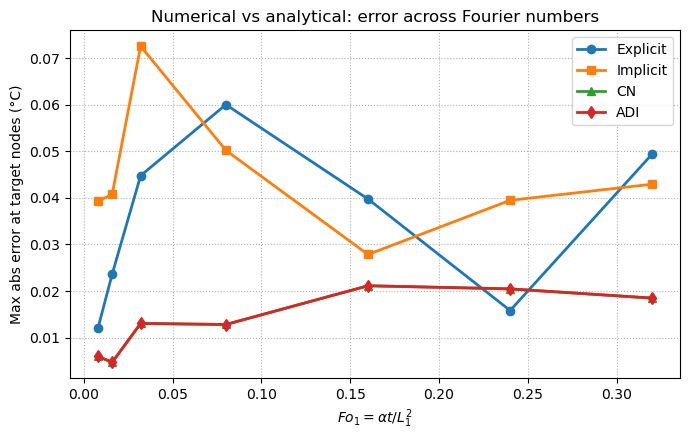

In [89]:
#| label: fig-error
#| fig-cap: 'Maximum error at the target nodes against the analytical solution for different Fourier numbers.'
fig_fo, ax_fo = plt.subplots(figsize=(7, 4.5))
for col, marker in zip(["Explicit err (°C)",\
                        "Implicit err (°C)", "CN err (°C)", "ADI err (°C)"],
                        ["o", "s", "^", "d"]):
    ax_fo.plot(df_fo["Fo1"], df_fo[col], marker=marker, linewidth=2, label=col.split(" err")[0])
ax_fo.set_xlabel(r"$Fo_1 = \alpha t / L_1^2$")
ax_fo.set_ylabel("Max abs error at target nodes (\u00b0C)")
ax_fo.set_title("Numerical vs analytical: error across Fourier numbers")
ax_fo.legend(); ax_fo.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


# Task (d): Scheme Comparison and ADI Attractiveness

We compare all four schemes on **cost** — time steps, CPU time, and (for ADI) the number of tridiagonal solves per step — needed to reach a fixed target, first at a common time horizon (t = 100 s) and then at a **matched target accuracy**, before discussing why ADI is theoretically attractive for 2D problems relative to a fully implicit scheme solved with a general (non-ADI) linear solver.

In [91]:
#| label: tbl-cost100
#| tbl-cap: 'Scheme comparison at $t=100$ s (temperatures and maximum error in $^\circ$C).'
# Task (d): Cost comparison at a common time horizon (t = 100 s)
target_time = 100.0

dt_explicit = 0.3  # Fo = 0.19
dt_implicit = 1.0  # Unconditionally stable

results_data = []

# Analytical Baseline
ana_vals = [analytical_T(cx, cy, target_time) for cx, cy in target_coords]
results_data.append(["Analytical", "N/A", "N/A", round(ana_vals[0],4), round(ana_vals[1],4), round(ana_vals[2],4), 0.0, 0.0])

methods = [
    ("Explicit", solve_explicit, dt_explicit),
    ("Fully Implicit", solve_implicit, dt_implicit),
    ("Crank-Nicolson", solve_crank_nicolson, dt_implicit),
    ("ADI (PR)", solve_adi, dt_implicit)
]

for name, func, dt in methods:
    n_steps = int(target_time / dt)
    t0 = time.time()
    T_grid, _, _ = func(target_time, dt)
    cpu_time = time.time() - t0

    t_vals = [T_grid[idx_i, idx_j] for idx_i, idx_j in target_indices]
    max_error = max([abs(x - y) for x, y in zip(ana_vals, t_vals)])

    results_data.append([name, dt, n_steps, round(t_vals[0],4), round(t_vals[1],4),\
                         round(t_vals[2],4), round(max_error,4), round(cpu_time,4)])

# Generate professional pandas table output
cols = ["Method", "dt (s)", "Steps", "T(0,0)", "T(a/4,0)", "T(0,b/4)", "Max err", "CPU (s)"]
df_results = pd.DataFrame(results_data, columns=cols)
df_results.set_index("Method", inplace=True)
display(df_results)

,dt (s),Steps,"T(0,0)","T(a/4,0)","T(0,b/4)",Max err,CPU (s)
Method,,,,,,,
Analytical,N/A,N/A,189.1416,184.9376,185.3820,0.0000,0.0000
Explicit,0.3,333,189.1784,184.9774,185.4174,0.0398,0.0884
Fully Implicit,1.0,100,189.1321,184.9654,185.3818,0.0279,0.0238
Crank-Nicolson,1.0,100,189.1538,184.9587,185.3953,0.0211,0.0478
ADI (PR),1.0,100,189.1538,184.9587,185.3953,0.0211,0.1231


**Effect of choosing $\Delta t$:  0.3 s vs 0.1 s for the Explicit scheme**

The Explicit scheme is run at $\Delta t=0.3\,$s throughout this notebook (see the cost tables in Task (d)). On this grid ($\Delta x=2.5\,$mm) that
gives $Fo_{\mathrm{exp}}=\alpha\Delta t/\Delta x^2\approx0.192$ -- about 77% of the $Fo\le1/4$ stability
ceiling derived in Task (a). That's a deliberate choice, not the largest stable step: it leaves a
safety margin rather than running right at the edge of instability, while still keeping the step count
(and hence CPU time) low. Halving $\Delta t$ to $0.1\,$s drops $Fo_{\mathrm{exp}}$ to about $0.064$ (only 26% of the limit) and, because the explicit truncation error is $O(\Delta t)$, it roughly halves the error too. It costs $3.33\times$ as many time steps to reach the same $t_{\mathrm{final}}$, so
roughly $3\times$ the CPU time for a $\approx2\times$ reduction in error. The cell below runs both and shows the actual numbers.

**The other three schemes are uncoditionally stable.** Fully Implicit,
Crank-Nicolson, and ADI never have a $Fo$ ceiling to respect (their amplification factor stays
$\le1$ for *any* $\Delta t$). That doesn't mean their answers are accurate at any $\Delta t$ -- large
steps still lose accuracy, as the convergence plot in @fig-conv shows: we can pick a large
step for a cheap, roughly-accurate answer, or a small step for a precise one, and we will never
get an oscillating or unstable solution just because the step was "too big" the way Explicit
would. Concretely here: $\Delta t_{\mathrm{implicit}}=1.0\,$s above is already $3.3\times$ the Explicit
step, needs no stability check at all, and is still *more* accurate than Explicit at $\Delta t=0.3\,$s
that combination (bigger step **and** lower error) is only possible because the scheme isn't fighting a stability limit in the first place.

In [93]:
#| label: tbl-dt
#| tbl-cap: 'Explicit scheme: effect of the time step at $t=100$ s.'
# dt = 0.3 s vs 0.1 s for the Explicit scheme:
dt_options = [0.3, 0.1]
rows_dt = []
for dt_test in dt_options:
    Fo_test = alpha * dt_test / dx**2
    t0 = time.time()
    T_e, _, _ = solve_explicit(target_time, dt_test)
    cpu = time.time() - t0
    vals = [T_e[i, j] for i, j in target_indices]
    err = max(abs(a - v) for a, v in zip(ana_vals, vals))
    n_steps = int(target_time / dt_test)
    rows_dt.append([dt_test, Fo_test, f"{100*Fo_test/0.25:.0f}%",\
                    n_steps, round(err, 4), round(cpu, 4)])

df_dt = pd.DataFrame(rows_dt, columns=["dt (s)", "Fo_exp", "% of Fo limit",
                                        "N steps", "Max Error (°C)", "CPU Time (s)"])
df_dt.set_index("dt (s)", inplace=True)
display(df_dt)

,Fo_exp,% of Fo limit,N steps,Max Error (°C),CPU Time (s)
dt (s),,,,,
0.3,0.192,77%,333,0.0398,0.0807
0.1,0.064,26%,1000,0.0204,0.2535


**Cost at a fixed accuracy.** @tbl-cost100 above fixes `dt` per scheme (not accuracy), so the *Max Error* column differs across methods and isn't a fair like-for-like cost comparison. To isolate the true cost-for-accuracy trade-off, we now fix an error tolerance and, for each scheme, find the largest `dt` (i.e. fewest steps) that still meets it:

In [109]:
#| label: tbl-fixed
#| tbl-cap: 'Cost to reach a maximum error of 0.05 $^\circ$C at $t=100$ s.'
# Task (d): Cost to reach a FIXED accuracy
tol = 0.05  # deg C target accuracy at t = 100 s

explicit_dt_max = 0.25 * dx**2 / alpha  # stability ceiling, Fo <= 0.25
candidate_dt = {
    "Explicit":        sorted([d for d in [0.39, 0.3, 0.2, 0.1, 0.05]\
                               if d <= explicit_dt_max], reverse=True),
    "Fully Implicit":  [4.0, 2.0, 1.0, 0.5, 0.25],
    "Crank-Nicolson":  [4.0, 2.0, 1.0, 0.5, 0.25],
    "ADI (PR)":        [4.0, 2.0, 1.0, 0.5, 0.25],
}
solver_fn = {
    "Explicit": solve_explicit,
    "Fully Implicit": solve_implicit,
    "Crank-Nicolson": solve_crank_nicolson,
    "ADI (PR)": solve_adi,
}

fixed_rows = []
for name in ["Explicit", "Fully Implicit", "Crank-Nicolson", "ADI (PR)"]:
    fn = solver_fn[name]
    chosen = None
    # Walk from the largest (cheapest) candidate dt down until the error tolerance is met.
    for dt_try in candidate_dt[name]:
        t0 = time.time()
        if name == "ADI (PR)":
            T_grid, _, _, n_solves_try = fn(target_time, dt_try, count_solves=True)
        else:
            T_grid, _, _ = fn(target_time, dt_try)
            n_solves_try = None
        cpu = time.time() - t0

        vals = [T_grid[i, j] for i, j in target_indices]
        err = max(abs(x - y) for x, y in zip(ana_vals, vals))
        chosen = (dt_try, err, cpu, n_solves_try)
        if err <= tol:
            break 
        # smallest dt tried that meets the tolerance, stop, no need to go finer

    dt_f, err_f, cpu_f, nsolve_f = chosen
    n_steps_f = int(target_time / dt_f)
    fixed_rows.append([name, dt_f, n_steps_f, round(err_f, 4), round(cpu_f, 4),
                        nsolve_f if nsolve_f is not None else "-"])

df_fixed = pd.DataFrame(fixed_rows, columns=["Method", "dt (s) used", "Steps",
                                              "Max err (°C)", "CPU (s)", "ADI solves"])
df_fixed.set_index("Method", inplace=True)
display(df_fixed)

,dt (s) used,Steps,Max err (°C),CPU (s),ADI solves
Method,,,,,
Explicit,0.3,333,0.0398,0.0831,-
Fully Implicit,2.0,50,0.0342,0.0222,-
Crank-Nicolson,4.0,25,0.0220,0.0096,-
ADI (PR),4.0,25,0.0220,0.0322,850


The explicit scheme requires an extremely small time step to satisfy the stability criterion
($Fo\le1/4$). While the cost per step is negligible, the sheer number of required steps inflates
overall CPU time, and that step-size ceiling gets tighter, quadratically, on any finer grid.

The fully implicit and Crank-Nicolson schemes remove the stability restriction, permitting much
larger time steps bounded only by accuracy requirements. However, they couple every node in
the 2D grid simultaneously into one linear system per step.

**Why ADI is theoretically attractive for 2D problems:** ADI achieves unconditionally stable
implicit time marching without a full 2D matrix solve. By alternating directions across a split
time step, it decouples the 2D problem into independent 1D problems: a grid with $N_x$ columns and
$N_y$ rows needs exactly $N_x+N_y$ tridiagonal solves per full step, each $O(N)$ via the Thomas
algorithm, asymptotically cheaper per step than forming and factoring one large 2D sparse system,
and dramatically cheaper than a *dense* 2D solve.

**The fixed-accuracy table tells the other half of the story.** Because ADI (like Crank-Nicolson) is second-order accurate and unconditionally stable, it can take the same large `dt = 4.0` s that Crank-Nicolson uses, reaching the target error in only 25 steps -- half of Fully Implicit's 50 steps -- which *does* confirm the theoretical step-count advantage. Its wall-clock time is still the slowest of the three implicit methods.


### Additional visualizations
### Temperature and error fields
@fig-fields shows the temperature field for different schemes at t = 100 s where the dashed cyan curve represents the analytical isotherms.

**Transient tracking of temperature** (@fig-transient) ADI is plotted against the analytical benchmark (dashed)
at the center and the two quarter-points, using $\Delta t=2.0\,$s (a step that costs only 50 time
steps to reach $t=100\,$s. The three curves separate mainly because $(a/4,0)$ sits
closer to the more-restrictive $x$-face ($Bi_1=0.333>Bi_2=0.200$), so it cools faster than $(0,b/4)$,
which in turn cools faster than the center.

**$\Delta t$-convergence** (@fig-conv). Crank-Nicolson and ADI are labeled $O(\Delta t^2)$, but their
lines are comparatively flat across $\Delta t=1$-$10\,$s rather than showing a steep quadratic rise
because their *temporal* truncation error stays close to the fixed *spatial* truncation error floor
set by $\Delta x=2.5\,$mm across most of this range. Fully-Implicit, by contrast, rises
much more steeply from $\Delta t=1\,$s to $\Delta t=10\,$s.

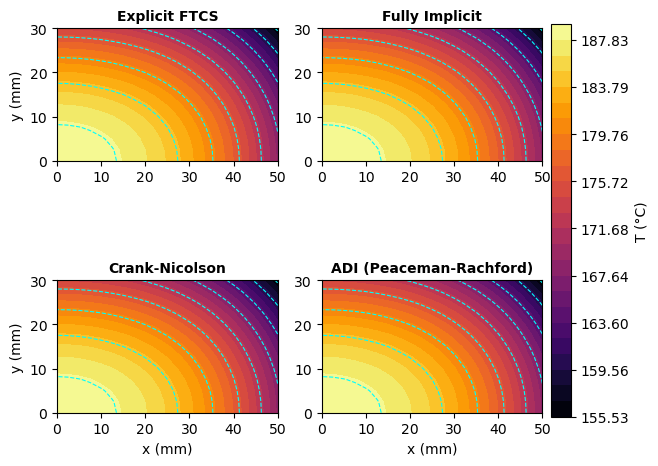

In [111]:
#| label: fig-fields
#| fig-cap: 'Quarter-domain temperature fields at $t=100$ s for the four schemes; dashed cyan lines are the analytical isotherms.'
#Quarter-domain temperature fields for all four schemes, on a shared
# temperature scale, with the analytical solution overlaid as dashed isotherms.
field_time = 100.0
T_ana_grid = analytical_grid(field_time)
T_exp_f, _, _ = solve_explicit(field_time, dt_explicit)
T_imp_f, _, _ = solve_implicit(field_time, dt_implicit)
T_cn_f,  _, _ = solve_crank_nicolson(field_time, dt_implicit)
T_adi_f, _, _ = solve_adi(field_time, dt_implicit)

schemes = [("Explicit FTCS", T_exp_f),
           ("Fully Implicit", T_imp_f),
           ("Crank-Nicolson", T_cn_f),
           ("ADI (Peaceman-Rachford)", T_adi_f)]

Tvals_all = [T_ana_grid] + [Tg for _, Tg in schemes]
vmin, vmax = min(f.min() for f in Tvals_all), max(f.max() for f in Tvals_all)

fig_field, axes = plt.subplots(2, 2, figsize=(7.5, 6))
axes = axes.ravel()

for col, (name, Tg) in enumerate(schemes):
    ax = axes[col]
    cf = ax.contourf(x_grid*1000, y_grid*1000, Tg.T,\
                     levels=np.linspace(vmin, vmax, 26), cmap="inferno")
    ax.contour(x_grid*1000, y_grid*1000, T_ana_grid.T, levels=8, colors="cyan",
               linewidths=0.8, linestyles="--")
    ax.set_title(name, fontsize=10, fontweight="bold")
    if col >= 2:
        ax.set_xlabel("x (mm)")
    if col % 2 == 0:
        ax.set_ylabel("y (mm)")
    ax.set_aspect("equal")

fig_field.colorbar(cf, ax=axes.tolist(), shrink=0.85, pad=0.015, label="T (°C)")
plt.show()


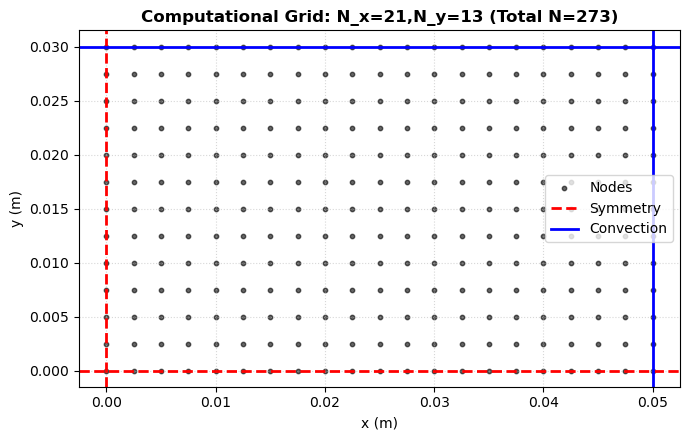

In [113]:
#| label: fig-grid
#| fig-cap: 'Computational grid for the quarter domain.'
fig, ax1 = plt.subplots(figsize=(7, 4.5))
X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
ax1.scatter(X.flatten(), Y.flatten(), color='black', s=10, alpha=0.6, label='Nodes')
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Symmetry')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.axvline(L1, color='blue', linestyle='-', linewidth=2, label='Convection')
ax1.axhline(L2, color='blue', linestyle='-', linewidth=2)
ax1.set_title(f'Computational Grid: N_x={Nx},\
N_y={Ny} (Total N={Nx*Ny})', fontsize=12, fontweight='bold')
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend()
plt.tight_layout()
plt.show()


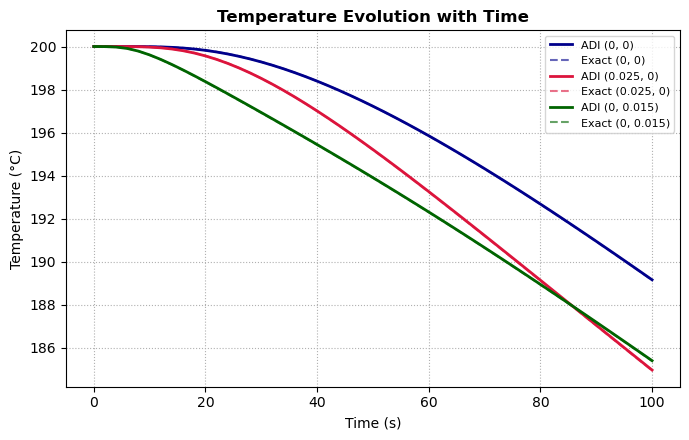

In [115]:
#| label: fig-transient
#| fig-cap: 'Transient temperature at the three target nodes: ADI (solid) against the analytical solution (dashed).'
fig, ax2 = plt.subplots(figsize=(7, 4.5))
_, t_hist_adi, history_adi = solve_adi(target_time, 2.0)
t_hist_ana, history_ana = get_analytical_history(target_time, 2.0)

colors = ['darkblue', 'crimson', 'darkgreen']
for idx, (coord, color) in enumerate(zip(target_coords, colors)):
    ax2.plot(t_hist_adi, history_adi[coord],\
             color=color, linewidth=2, label=f'ADI {coord}')
    ax2.plot(t_hist_ana, history_ana[coord],\
             color=color, linestyle='--', alpha=0.6, label=f'Exact {coord}')

ax2.set_title('Temperature Evolution with Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temperature (°C)')
ax2.grid(True, linestyle=':')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


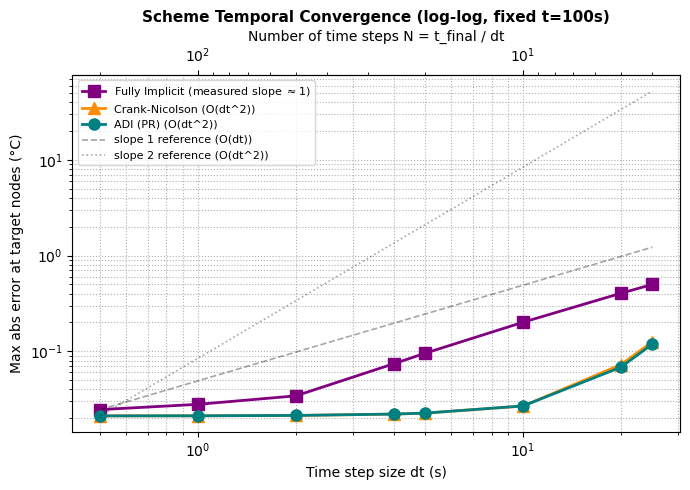

In [117]:
#| label: fig-conv
#| fig-cap: 'Temporal convergence at fixed $t=100$ s: error against time step for the three implicit schemes.'
# Plot 3: Comparative Convergence Plot (Error vs dt), t_final held FIXED at target_time.
# NOTE: the x-axis here is the STEP SIZE dt used to march to the same fixed final time,
# not the simulation clock -- it is a classic dt-refinement study, not a time history.
fig, ax3 = plt.subplots(figsize=(7, 5))
time_steps = [0.5, 1.0, 2.0, 4.0, 5.0, 10.0, 20.0, 25.0]   # all divide target_time evenly
errors = {'Fully Implicit': [], 'Crank-Nicolson': [], 'ADI (PR)': []}

for dt in time_steps:
    T_imp, _, _ = solve_implicit(target_time, dt)
    T_cn, _, _  = solve_crank_nicolson(target_time, dt)
    T_adi, _, _ = solve_adi(target_time, dt)
    
    err_imp = max([abs(ana_vals[k] - T_imp[i, j]) for k, (i, j) in enumerate(target_indices)])
    err_cn  = max([abs(ana_vals[k] - T_cn[i, j])  for k, (i, j) in enumerate(target_indices)])
    err_adi = max([abs(ana_vals[k] - T_adi[i, j]) for k, (i, j) in enumerate(target_indices)])
    
    errors['Fully Implicit'].append(err_imp)
    errors['Crank-Nicolson'].append(err_cn)
    errors['ADI (PR)'].append(err_adi)

ax3.plot(time_steps, errors['Fully Implicit'],\
         's-', color='purple', linewidth=2, markersize=8,\
         label='Fully Implicit (measured slope $\\approx$1)')
ax3.plot(time_steps, errors['Crank-Nicolson'],\
         '^-', color='darkorange', linewidth=2, markersize=8,\
         label='Crank-Nicolson (O(dt^2))')
ax3.plot(time_steps, errors['ADI (PR)'],\
         'o-', color='teal', linewidth=2, markersize=8,\
         label='ADI (PR) (O(dt^2))')

# Reference slope-1 / slope-2 guide lines, anchored at the smallest dt, so the
# *shape* of each curve can be checked against its theoretical order directly.
dt_ref = np.array([time_steps[0], time_steps[-1]])
ax3.plot(dt_ref, errors['Fully Implicit'][0]*(dt_ref/dt_ref[0])**1,\
         'k--', alpha=0.35, linewidth=1.2, label='slope 1 reference (O(dt))')
ax3.plot(dt_ref, errors['Crank-Nicolson'][0]*(dt_ref/dt_ref[0])**2,\
         'k:',  alpha=0.35, linewidth=1.2, label='slope 2 reference (O(dt^2))')

ax3.set_title('Scheme Temporal Convergence (log-log, fixed t=100s)',\
              fontsize=11, fontweight='bold', pad=38)
ax3.set_xlabel('Time step size dt (s)')
ax3.set_ylabel('Max abs error at target nodes (°C)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, which='both', linestyle=':')
ax3.legend(fontsize=8)

# Secondary top axis: same data, but labelled by number of time steps N = target_time/dt,
# which is what actually drives CPU cost (ties this plot to the Task (d) discussion).
def dt_to_n(dt):
    dt = np.asarray(dt, dtype=float)
    with np.errstate(divide='ignore'):
        return np.where(dt > 0, target_time / dt, np.inf)
ax3_top = ax3.secondary_xaxis('top', functions=(dt_to_n, dt_to_n))
ax3_top.set_xlabel('Number of time steps N = t_final / dt')

plt.tight_layout()
plt.show()